<a href="https://www.kaggle.com/code/sonawanelalitsunil/cpi-inflation-trends-ml-100?scriptVersionId=228807209" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cpi-inflation-analysis-and-forecasting/CPI_dataset.csv


## Title: CPI & Inflation Trends 📊

#### Descriptions: Analyzing past inflation patterns and forecasting future trends to understand economic shifts. 🔎📈

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/cpi-inflation-analysis-and-forecasting/CPI_dataset.csv')

In [3]:
df.head()

,consumer_price_index_item,month_of_forecast,year_of_forecast,year_being_forecast,attribute,forecast_percent_change
0,All food,July,2002,2003,Lower bound of prediction interval,-0.2
1,Dairy products,August,2002,2003,Lower bound of prediction interval,-8.9
2,Dairy products,July,2002,2003,Upper bound of prediction interval,8.1
3,Dairy products,July,2002,2003,Mid point of prediction interval,-1.2
4,Dairy products,July,2002,2003,Lower bound of prediction interval,-9.7


In [4]:
df.tail()

,consumer_price_index_item,month_of_forecast,year_of_forecast,year_being_forecast,attribute,forecast_percent_change
41619,Food at home,February,2023,2023,Lower bound of prediction interval,5.6
41620,Food at home,January,2023,2023,Upper bound of prediction interval,11.7
41621,Food at home,January,2023,2023,Mid point of prediction interval,8.0
41622,Food at home,January,2023,2023,Lower bound of prediction interval,4.5
41623,Food at home,March,2023,2023,Lower bound of prediction interval,5.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41624 entries, 0 to 41623
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   consumer_price_index_item  41624 non-null  object 
 1   month_of_forecast          41624 non-null  object 
 2   year_of_forecast           41624 non-null  int64  
 3   year_being_forecast        41624 non-null  int64  
 4   attribute                  41624 non-null  object 
 5   forecast_percent_change    41621 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 1.9+ MB


In [6]:
df.describe()

,year_of_forecast,year_being_forecast,forecast_percent_change
count,41624.000000,41624.000000,41621.000000
mean,2013.009129,2013.343936,2.599438
std,6.121562,6.122425,5.051802
min,2002.000000,2003.000000,-37.000000
25%,2008.000000,2008.000000,0.500000
50%,2013.000000,2013.000000,2.500000
75%,2018.000000,2019.000000,4.000000
max,2023.000000,2024.000000,62.300000


In [7]:
df.isnull().sum()

consumer_price_index_item    0
month_of_forecast            0
year_of_forecast             0
year_being_forecast          0
attribute                    0
forecast_percent_change      3
dtype: int64

In [8]:
df.duplicated().sum()

460

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

0

In [11]:
df.shape

(41164, 6)

In [12]:
df.corr

<bound method DataFrame.corr of       consumer_price_index_item month_of_forecast  year_of_forecast  \
0                      All food              July              2002   
1                Dairy products            August              2002   
2                Dairy products              July              2002   
3                Dairy products              July              2002   
4                Dairy products              July              2002   
...                         ...               ...               ...   
41605                  All food          February              2023   
41609               Other meats           January              2023   
41613               Other foods           January              2023   
41619              Food at home          February              2023   
41620              Food at home           January              2023   

       year_being_forecast                           attribute  \
0                     2003  Lower bound of predic

In [13]:
df.dtypes

consumer_price_index_item     object
month_of_forecast             object
year_of_forecast               int64
year_being_forecast            int64
attribute                     object
forecast_percent_change      float64
dtype: object

In [14]:
df.columns

Index(['consumer_price_index_item', 'month_of_forecast', 'year_of_forecast',
       'year_being_forecast', 'attribute', 'forecast_percent_change'],
      dtype='object')

## data visualizations

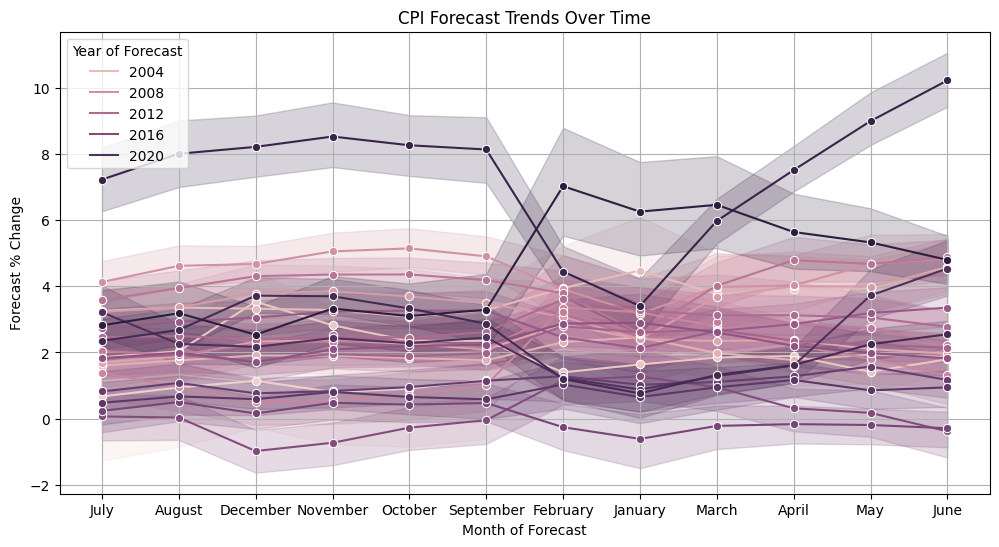

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="month_of_forecast", y="forecast_percent_change", hue="year_of_forecast", marker="o")
plt.title("CPI Forecast Trends Over Time")
plt.xlabel("Month of Forecast")
plt.ylabel("Forecast % Change")
plt.legend(title="Year of Forecast")
plt.grid(True)
plt.show()

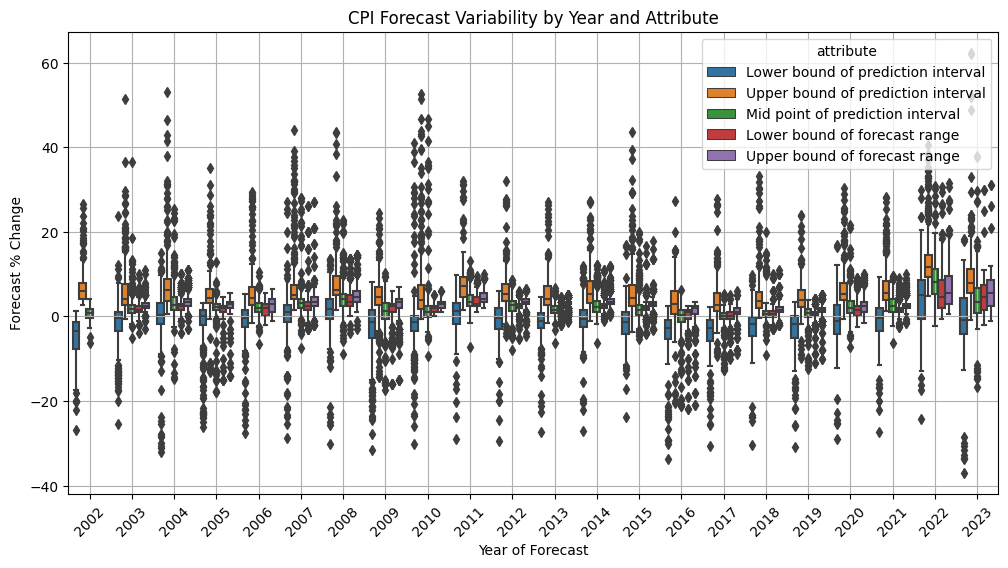

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="year_of_forecast", y="forecast_percent_change", hue="attribute")
plt.title("CPI Forecast Variability by Year and Attribute")
plt.xlabel("Year of Forecast")
plt.ylabel("Forecast % Change")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

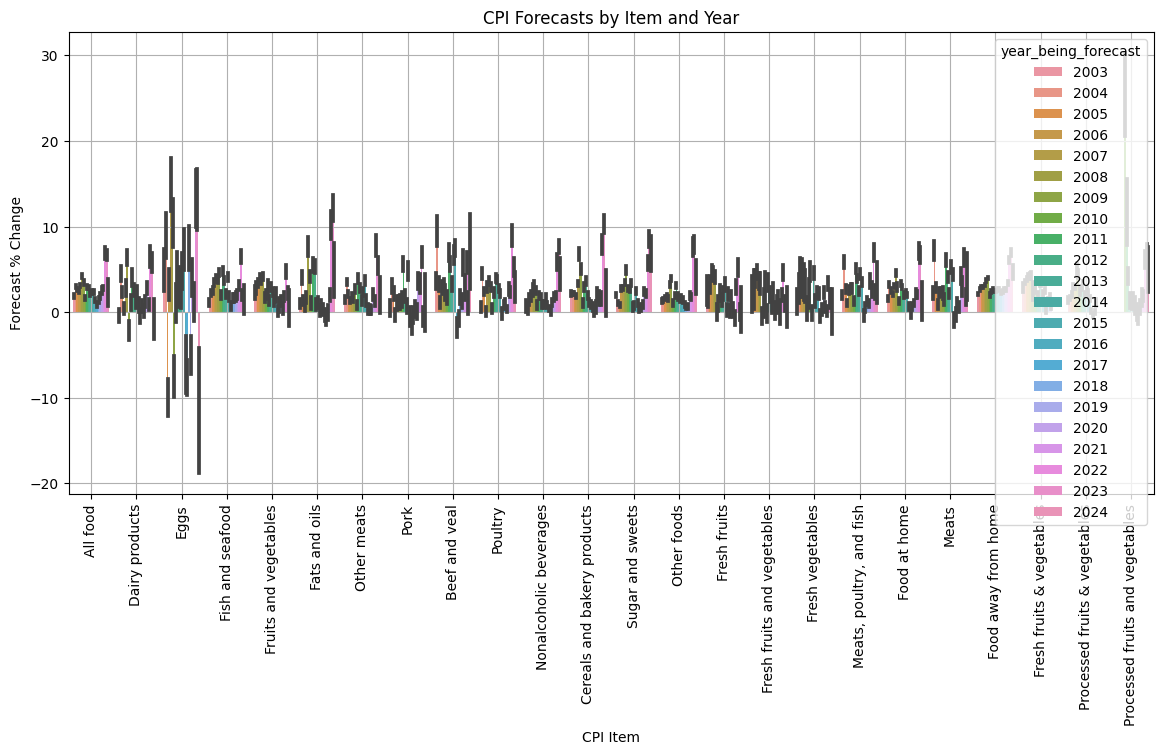

In [17]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x="consumer_price_index_item", y="forecast_percent_change", hue="year_being_forecast")
plt.title("CPI Forecasts by Item and Year")
plt.xlabel("CPI Item")
plt.ylabel("Forecast % Change")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

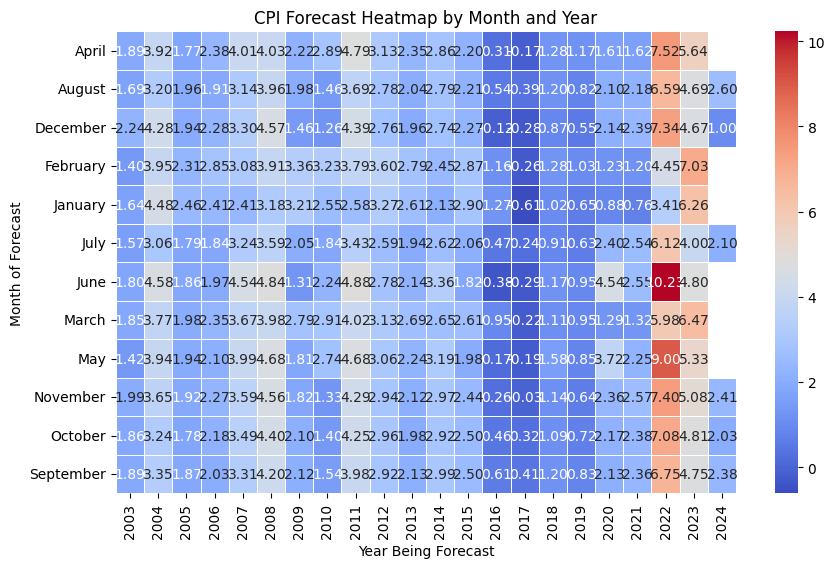

In [18]:
heatmap_data = df.pivot_table(index="month_of_forecast", columns="year_being_forecast", values="forecast_percent_change", aggfunc="mean")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("CPI Forecast Heatmap by Month and Year")
plt.xlabel("Year Being Forecast")
plt.ylabel("Month of Forecast")
plt.show()

## Predictive modeling

In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [20]:
# Create features for modeling
model_df = df.copy()

In [21]:
# Convert month name to numeric value
df['month_numeric'] = pd.to_datetime(df['month_of_forecast'], format='%B').dt.month

# Ensure columns are correctly assigned before converting
df['date'] = pd.to_datetime(df[['year_of_forecast', 'month_numeric']].assign(day=1).rename(columns={'year_of_forecast': 'year', 'month_numeric': 'month'}))


In [22]:
print(df.columns)

Index(['consumer_price_index_item', 'month_of_forecast', 'year_of_forecast',
       'year_being_forecast', 'attribute', 'forecast_percent_change',
       'month_numeric', 'date'],
      dtype='object')


In [23]:
# Create lagged features
food_items_pivot = df.pivot_table(
    index=['date'], 
    columns='consumer_price_index_item',
    values='forecast_percent_change',
    aggfunc='mean'
).reset_index()


In [24]:
# For simplicity, let's focus on overall CPI trends
overall_cpi = df.groupby('date')['forecast_percent_change'].mean().reset_index()

In [25]:
# Create lag features (1-6 months)
for lag in range(1, 7):
    overall_cpi[f'lag_{lag}'] = overall_cpi['forecast_percent_change'].shift(lag)

# Create rolling mean features
for window in [3, 6, 12]:
    overall_cpi[f'rolling_mean_{window}'] = overall_cpi['forecast_percent_change'].rolling(window).mean()

# Create year and month features
overall_cpi['year'] = overall_cpi['date'].dt.year
overall_cpi['month'] = overall_cpi['date'].dt.month

# Create seasonal dummy variables
overall_cpi = pd.get_dummies(overall_cpi, columns=['month'], prefix='month')

# Drop NA values created by lag and rolling features
overall_cpi = overall_cpi.dropna()

print("Prepared dataset for modeling:")
display(overall_cpi.head())


Prepared dataset for modeling:


,date,forecast_percent_change,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,rolling_mean_3,rolling_mean_6,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
11,2003-06-01,1.795327,1.418692,1.892523,1.848598,1.400000,1.637383,1.146032,1.702181,1.665421,...,False,False,False,True,False,False,False,False,False,False
12,2003-07-01,1.856542,1.795327,1.418692,1.892523,1.848598,1.400000,1.637383,1.690187,1.701947,...,False,False,False,False,True,False,False,False,False,False
13,2003-08-01,2.035981,1.856542,1.795327,1.418692,1.892523,1.848598,1.400000,1.895950,1.807944,...,False,False,False,False,False,True,False,False,False,False
14,2003-09-01,2.353738,2.035981,1.856542,1.795327,1.418692,1.892523,1.848598,2.082087,1.892134,...,False,False,False,False,False,False,True,False,False,False
15,2003-10-01,2.353271,2.353738,2.035981,1.856542,1.795327,1.418692,1.892523,2.247664,1.968925,...,False,False,False,False,False,False,False,True,False,False


In [26]:
# Prepare features and target
X = overall_cpi.drop(['date', 'forecast_percent_change'], axis=1)
y = overall_cpi['forecast_percent_change']

In [27]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (247, 22)
Target vector shape: (247,)


In [28]:
# Split the data
from sklearn.model_selection import train_test_split

In [29]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [30]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    # Return results
    results = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'model': model,
        'test_pred': test_pred
    }
    
    return results

In [31]:
# Standardize features for certain models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Create a dictionary to store models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

In [33]:
# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    if name in ['SVR']:
        # SVR works better with scaled features
        model_results = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        model_results = evaluate_model(model, X_train, X_test, y_train, y_test)
    results[name] = model_results
    print(f"{name} - Test RMSE: {model_results['test_rmse']:.4f}, Test R²: {model_results['test_r2']:.4f}")
    

Training Linear Regression...
Linear Regression - Test RMSE: 0.0000, Test R²: 1.0000
Training Ridge Regression...
Ridge Regression - Test RMSE: 0.2447, Test R²: 0.9907
Training Lasso Regression...
Lasso Regression - Test RMSE: 0.7928, Test R²: 0.9025
Training Random Forest...
Random Forest - Test RMSE: 1.7897, Test R²: 0.5033
Training Gradient Boosting...
Gradient Boosting - Test RMSE: 1.8565, Test R²: 0.4656
Training SVR...
SVR - Test RMSE: 2.9213, Test R²: -0.3232


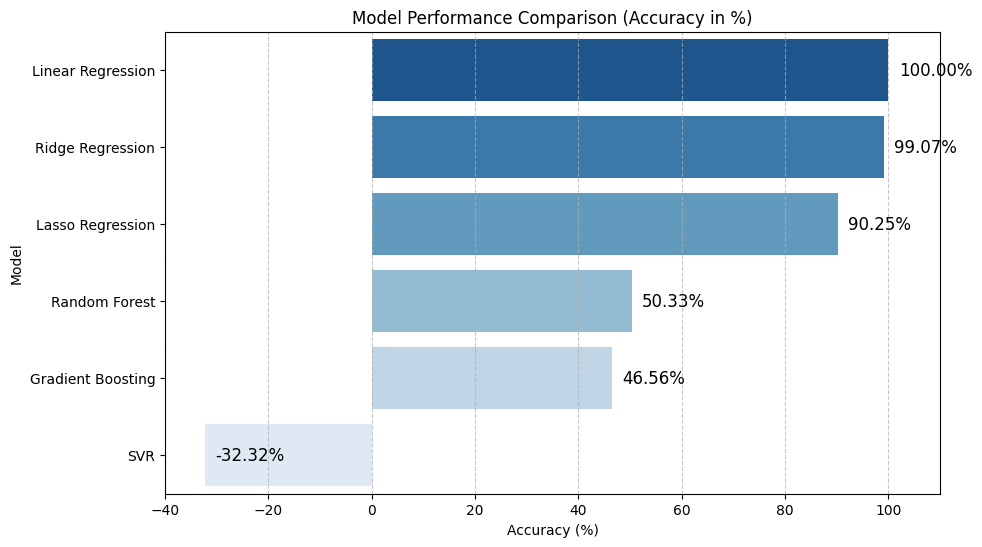

In [34]:
# Model names and their respective accuracy percentages
models = ["Linear Regression", "Ridge Regression", "Lasso Regression", "Random Forest", "Gradient Boosting", "SVR"]
accuracy = [100.00, 99.07, 90.25, 50.33, 46.56, -32.32]

# Set up the figure
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracy, y=models, palette="Blues_r")  # Reverse Blues palette for better contrast

# Add labels and title
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("Model Performance Comparison (Accuracy in %)")
plt.xlim(-40, 110)  # Adjust limits for visibility

# Display values on bars
for index, value in enumerate(accuracy):
    plt.text(value + 2, index, f"{value:.2f}%", va='center', fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

## Thank you!!!!...pls upvote!!